# Exercise 4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams.update({"image.cmap": "viridis"})

**Linear Regression**

The goal of this exercise is to explore a simple linear regression problem based on Portugese white wine.

The dataset is based on
Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. **Modeling wine preferences by data mining from physicochemical properties**. Published in Decision Support Systems, Elsevier, 47(4):547-553, 2009.



In [ ]:
# The code snippet below is responsible for downloading the dataset
# - for example when running via Google Colab.
#
# You can also directly download the file using the link if you work
# with a local setup (the !wget command will work either way assuming
# you are on a unix-based machine and have wget installed)
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

--2026-04-29 17:24:59--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-white.csv’

winequality-white.c     [   <=>              ] 258.23K   500KB/s    in 0.5s    

2026-04-29 17:25:00 (500 KB/s) - ‘winequality-white.csv’ saved [264426]



**Before we start**

The downloaded file contains data on 4989 wines. For each wine 11 features are recorded (column 0 to 10). The final columns contains the quality of the wine. This is what we want to predict. More information on the features and the quality measurement is provided in the original publication.

List of columns/features:
0. fixed acidity
1. volatile acidity
2. citric acid
3. residual sugar
4. chlorides
5. free sulfur dioxide
6. total sulfur dioxide
7. density
8. pH
9. sulphates
10. alcohol
11. quality



[file]: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

In [ ]:
# Before working with the data,
# we download and prepare all features

# load all examples from the file
data = np.genfromtxt('winequality-white.csv',delimiter=";",skip_header=1)

print(f"{data.shape = }")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12)
First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


# Problems


* First we want to understand the data better. Plot (`plt.hist`) the distribution of each of the features for the training data as well as the 2D distribution (either `plt.scatter` or `plt.hist2d`) of each feature versus quality. Also calculate the correlation coefficient (`np.corrcoef`) for each feature with quality. Which feature by itself seems most predictive for the quality?

* Calculate the linear regression weights. Numpy provides functions for matrix multiplication (`np.matmul`), matrix transposition (`.T`) and matrix inversion (`np.linalg.inv`).

* Use the weights to predict the quality for the test dataset. How
does your predicted quality compare with the true quality of the test data? Calculate the correlation coefficient between predicted and true quality and draw a scatter plot.

**Homework Submission**

When you submit your exercise sheet, please alwasy do two things

1) Generate a PDF of your iPython notebook. Submit this PDF through Studium (Uppsala)/Moodle (Dortmund).

2) Provide a link to your google colab notebook so that we can directly execute and test your code. To do that click on "share", change access to "anyone with the link", copy the link and add it as a comment to your submission on Studium (Uppsala)/Moodle (Dortmund).

# Hints

Formally, we want to find weights $w_i$ that minimize:
$$
\sum_{j}\left(\sum_{i} X_{i j} w_{i}-y_{j}\right)^{2}
$$
The index $i$ denotes the different features (properties of the wines) while the index $j$ runs over the different wines. The matrix $X_{ij}$ contains the training data, $y_j$ is the 'true' quality for sample $j$. The weights can be found by taking the first derivative of the above expression with respect to the weights and setting it to zero (the standard strategy for finding an extremum), and solving the corresponding system of equations (for a detailed derivation, see [here](https://en.wikipedia.org/wiki/Ordinary_least_squares)). The result is:
$$
\overrightarrow{\mathbf{w}}=\left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T} \overrightarrow{\mathbf{y}}
$$

In the end, you should have as many components of $w_i$ as there are features in the data (i.e. eleven in this case).

You can use `.shape` to inspect the dimensions of numpy tensors.


First we will understand our data. we will do three things to understand our data.
1. Plot the distribution of each feature
2. Plot each feature vs quality
3. Calculate the correlation coefficient

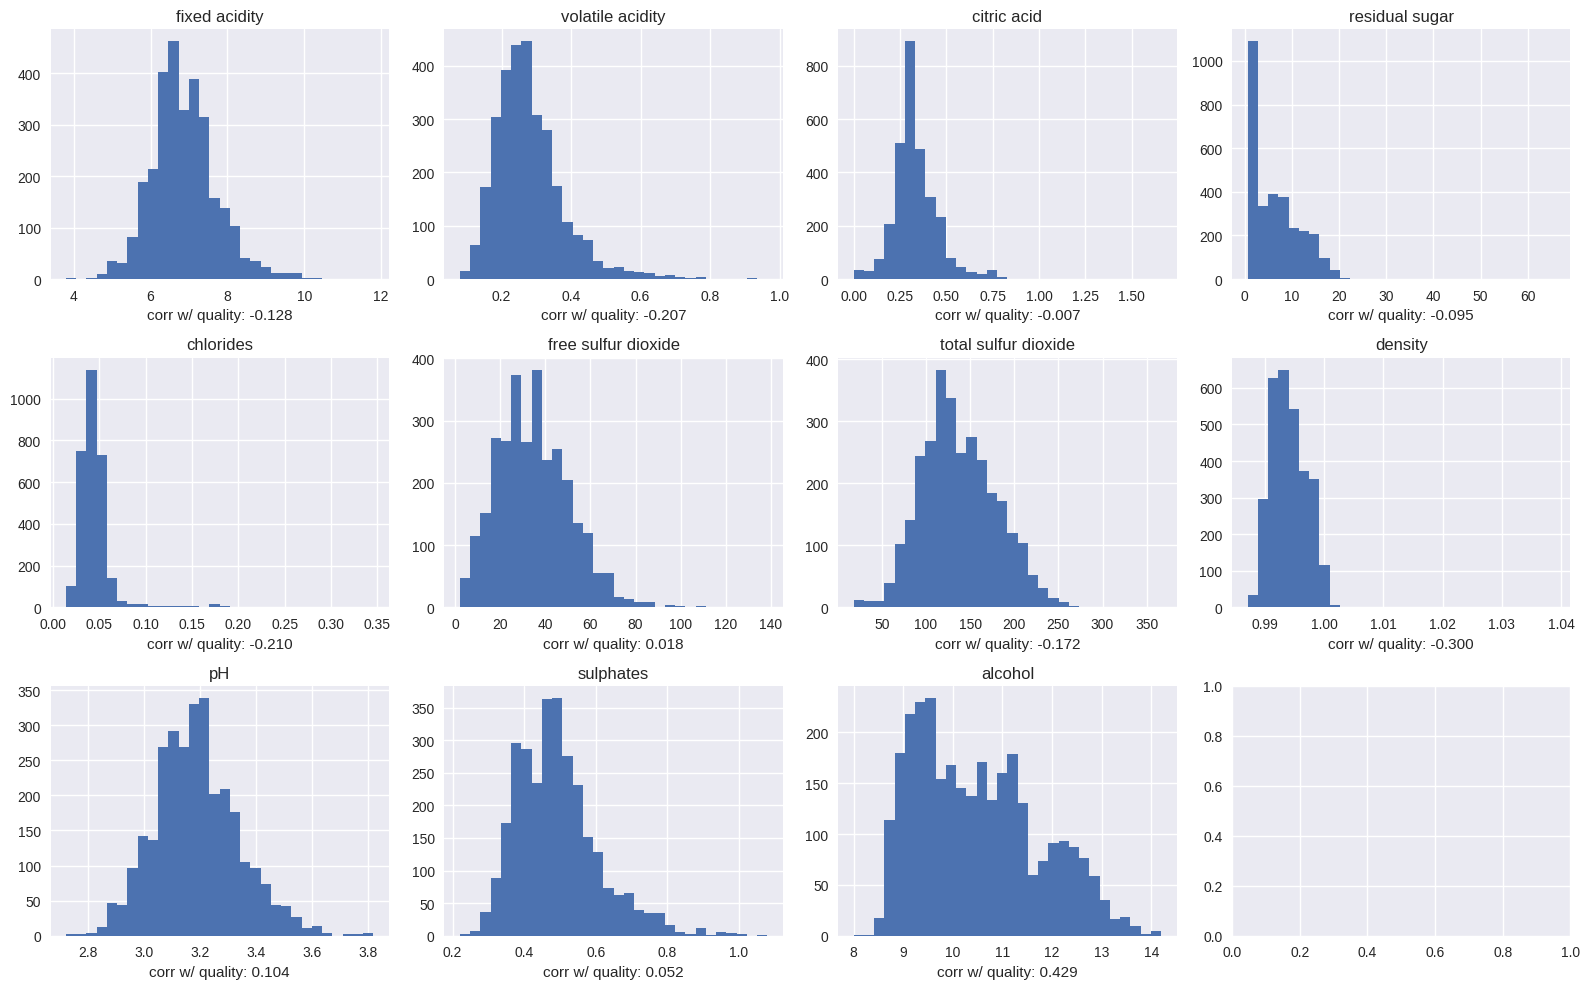

Most predictive feature: 'alcohol' (r = 0.429)


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()      # makes it easier to loop over

correlations = []

feature_names = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH", "sulphates", "alcohol"
]

for i, name in enumerate(feature_names):

    # 1. Distribution of the feature
    axes[i].hist(X_train[:, i], bins=30)
    axes[i].set_title(name)


    # 2. Correlation with quality
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    correlations.append(corr)
    axes[i].set_xlabel(f"corr w/ quality: {corr:.3f}")

plt.tight_layout()
plt.show()

# Which feature is most predictive?
best = np.argmax(np.abs(correlations))
print(f"Most predictive feature: '{feature_names[best]}' (r = {correlations[best]:.3f})")

In [ ]:
# Step by step so we can inspect each piece
XtX     = X_train.T @ X_train        # shape (11, 11)
XtX_inv = np.linalg.inv(XtX)         # shape (11, 11)
Xty     = X_train.T @ y_train        # shape (11,)

w = XtX_inv @ Xty                    # shape (11,) ← our weights!

print("Shape:", w.shape)  # Should be (11,)
print("Weights:")
for name, weight in zip(feature_names, w):
    print(f"  {name:25s}: {weight:+.4f}")





Shape: (11,)
Weights:
  fixed acidity            : -0.0687
  volatile acidity         : -2.0589
  citric acid              : -0.0290
  residual sugar           : +0.0218
  chlorides                : -1.1053
  free sulfur dioxide      : +0.0060
  total sulfur dioxide     : -0.0010
  density                  : +2.4199
  pH                       : +0.1406
  sulphates                : +0.3511
  alcohol                  : +0.3576


Correlation: 0.516


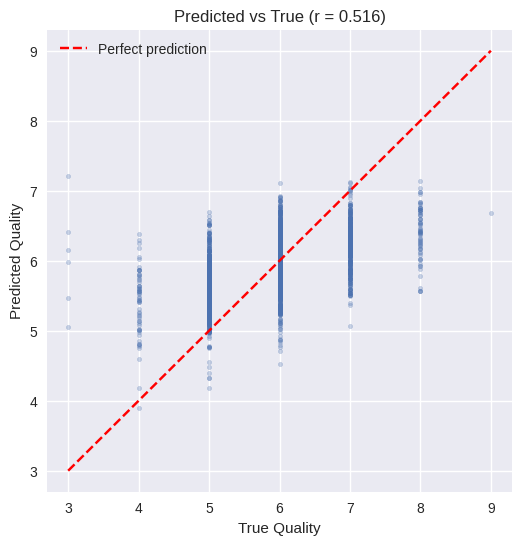

In [ ]:
# Step 1: predict on TEST data (not train!)
y_pred = X_test @ w          # shape (1898,)

# Step 2: correlation between predicted and true quality
corr = np.corrcoef(y_pred, y_test)[0, 1]
print(f"Correlation: {corr:.3f}")

# Step 3: scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.xlabel("True Quality")
plt.ylabel("Predicted Quality")
plt.title(f"Predicted vs True (r = {corr:.3f})")
plt.plot([3, 9], [3, 9], 'r--', label="Perfect prediction")
plt.legend()
plt.show()

In [ ]:
# Add a column of ones to both train and test
ones_train = np.ones((X_train.shape[0], 1))  # shape (3000, 1)
ones_test  = np.ones((X_test.shape[0], 1))   # shape (1898, 1)

X_train_b = np.hstack([X_train, ones_train])  # shape (3000, 12)
X_test_b  = np.hstack([X_test,  ones_test])   # shape (1898, 12)

# Same OLS formula as before — nothing else changes!
w_b = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

# Last element is the bias
print(f"Bias term: {w_b[-1]:.4f}")
print(f"Feature weights: {w_b[:-1]}")

# Predict
y_pred_b = X_test_b @ w_b

# Evaluate
corr_b = np.corrcoef(y_pred_b, y_test)[0, 1]
print(f"Correlation with bias: {corr_b:.3f}")

Bias term: 110.2366
Feature weights: [ 1.97051114e-02 -1.97246956e+00  3.38870770e-03  6.43013084e-02
 -5.74013322e-01  5.22151567e-03 -5.99515346e-04 -1.09453438e+02
  5.28044870e-01  5.10629056e-01  2.33036085e-01]
Correlation with bias: 0.529



r ≈ 0.52 means the model has genuinely learned something — but quality is hard to predict with perfect accuracy. Because:

Wine quality involves human taste — subjective and noisy
The relationship might not be perfectly linear
We're missing a bias term — which brings us to Phase 5!